In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
data=pd.read_csv("/content/zomato.csv",encoding='latin1')
print("Shape of the data set ",data.shape)
print("Data types")
print(data.info())
print("Checking for null values")
print(data.isnull().sum())
print("Checking for duplicate values")
print(data.duplicated().sum())

Shape of the data set  (9551, 21)
Data types
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9551 entries, 0 to 9550
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Restaurant ID         9551 non-null   int64  
 1   Restaurant Name       9551 non-null   object 
 2   Country Code          9551 non-null   int64  
 3   City                  9551 non-null   object 
 4   Address               9551 non-null   object 
 5   Locality              9551 non-null   object 
 6   Locality Verbose      9551 non-null   object 
 7   Longitude             9551 non-null   float64
 8   Latitude              9551 non-null   float64
 9   Cuisines              9542 non-null   object 
 10  Average Cost for two  9551 non-null   int64  
 11  Currency              9551 non-null   object 
 12  Has Table booking     9551 non-null   object 
 13  Has Online delivery   9551 non-null   object 
 14  Is delivering now     9551 

##5-line summary of what the data contains.

1. The dataset contains information about 9,551 restaurants from different cities and countries.
2. It includes details such as restaurant name, location, cuisines, average cost, ratings, and voting counts.
3. The dataset has 21 columns with numerical, categorical, and geographical data types.
4. Most columns do not contain missing values, while the “Cuisines” column has a few null values.
5. This dataset can be used to analyze restaurant trends, customer preferences, ratings, pricing, and online delivery services.

## Clean the Data

In [5]:
print(data.dropna(inplace=True))
print(data.isnull().sum())
print("duplicate row",data.duplicated().sum())
print(data.drop_duplicates(inplace=True))
print(data.drop(["Latitude","Longitude"],axis=1,inplace=True, errors='ignore'))

None
Restaurant ID           0
Restaurant Name         0
Country Code            0
City                    0
Address                 0
Locality                0
Locality Verbose        0
Longitude               0
Latitude                0
Cuisines                0
Average Cost for two    0
Currency                0
Has Table booking       0
Has Online delivery     0
Is delivering now       0
Switch to order menu    0
Price range             0
Aggregate rating        0
Rating color            0
Rating text             0
Votes                   0
dtype: int64
duplicate row 0
None
None


##Data Cleaning Process

1. Checked the dataset for missing values using `isnull().sum()`.
2. Found a few missing values in the “Cuisines” column and removed those rows using `dropna()`.
3. Checked for duplicate rows in the dataset.
4. Removed the “Longitude” and “Latitude” columns because they were not necessary for this analysis.
5. Verified the cleaned dataset before starting Exploratory Data Analysis (EDA).

#Exploratory Data Analysis (EDA)

##Question 1 :: Which city has the highest number of restaurants?

In [6]:
data['City'].value_counts().head()

,count
City,
New Delhi,5473
Gurgaon,1118
Noida,1080
Faridabad,251
Ghaziabad,25


##Question 2 :: Which cuisines are most popular?

In [7]:
data['Cuisines'].value_counts().head()

,count
Cuisines,
North Indian,936
"North Indian, Chinese",511
Chinese,354
Fast Food,354
"North Indian, Mughlai",334


##Question 3::Which restaurants have the highest ratings?

In [8]:
data[['Restaurant Name', 'Aggregate rating']].sort_values(by='Aggregate rating', ascending=False).head()

,Restaurant Name,Aggregate rating
9524,Gaga Manjero,4.9
3,Ooma,4.9
8,Spiral - Sofitel Philippine Plaza Manila,4.9
637,Sheroes Hangout,4.9
9514,Ministry of Crab,4.9


##Question 4::Does online delivery affect ratings?

In [9]:
data.groupby('Has Online delivery')['Aggregate rating'].mean()

,Aggregate rating
Has Online delivery,
No,2.463517
Yes,3.248837


##Question 5::Which city has the highest average restaurant rating?

In [10]:
data.groupby('City')['Aggregate rating'].mean().sort_values(ascending=False).head()

,Aggregate rating
City,
Inner City,4.900000
Quezon City,4.800000
Makati City,4.650000
Pasig City,4.633333
Mandaluyong City,4.625000


# Visualizations

## bar chart :: Which city has most restaurants

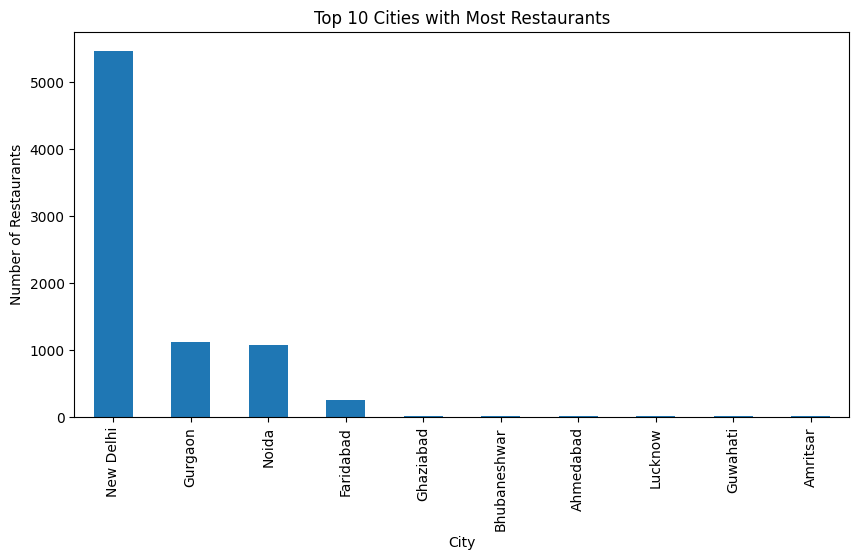

In [12]:
plt.figure(figsize=(10,5))
data['City'].value_counts().head(10).plot(kind='bar')
plt.title("Top 10 Cities with Most Restaurants")
plt.xlabel("City")
plt.ylabel("Number of Restaurants")
plt.show()

##Histogram Distribution of Ratings

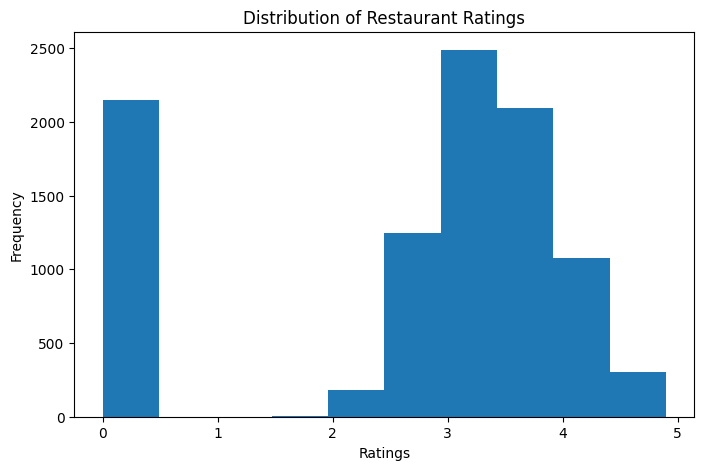

In [13]:
plt.figure(figsize=(8,5))
plt.hist(data['Aggregate rating'], bins=10)
plt.title("Distribution of Restaurant Ratings")
plt.xlabel("Ratings")
plt.ylabel("Frequency")
plt.show()

##Pie Chart Online Delivery Availability

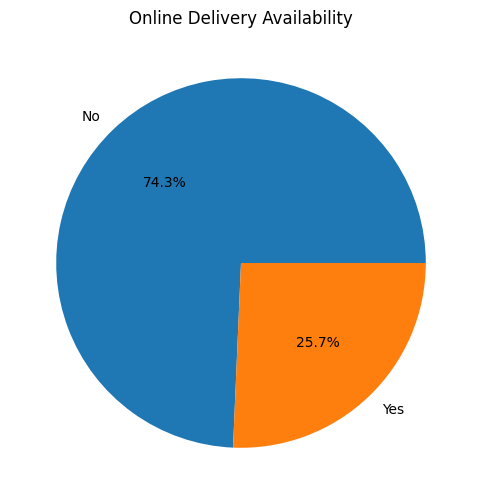

In [14]:
delivery = data['Has Online delivery'].value_counts()
plt.figure(figsize=(6,6))
plt.pie(delivery, labels=delivery.index, autopct='%1.1f%%')
plt.title("Online Delivery Availability")
plt.show()

##Scatter Plot Rating vs Average Cost

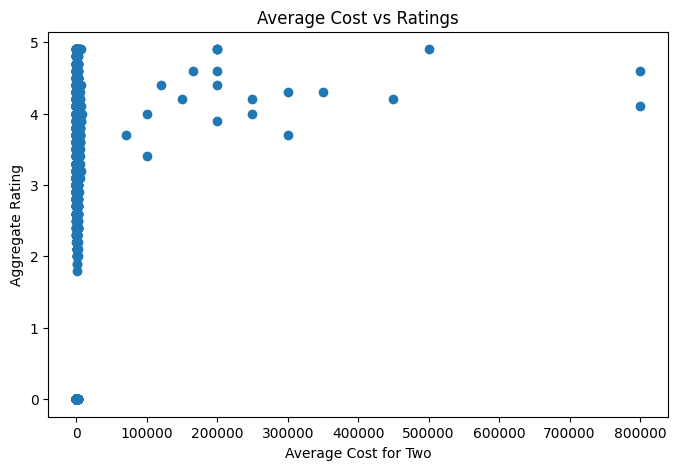

In [15]:
plt.figure(figsize=(8,5))
plt.scatter(data['Average Cost for two'], data['Aggregate rating'])
plt.title("Average Cost vs Ratings")
plt.xlabel("Average Cost for Two")
plt.ylabel("Aggregate Rating")
plt.show()

##Line Chart Restaurant Openings by Rating

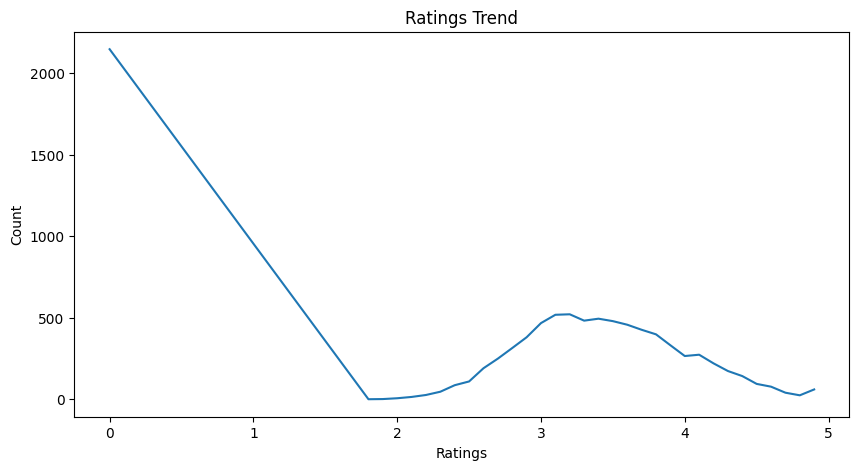

In [16]:
rating_counts = data['Aggregate rating'].value_counts().sort_index()
plt.figure(figsize=(10,5))
plt.plot(rating_counts.index, rating_counts.values)
plt.title("Ratings Trend")
plt.xlabel("Ratings")
plt.ylabel("Count")
plt.show()

##Heatmap Correlation Between Numerical Columns

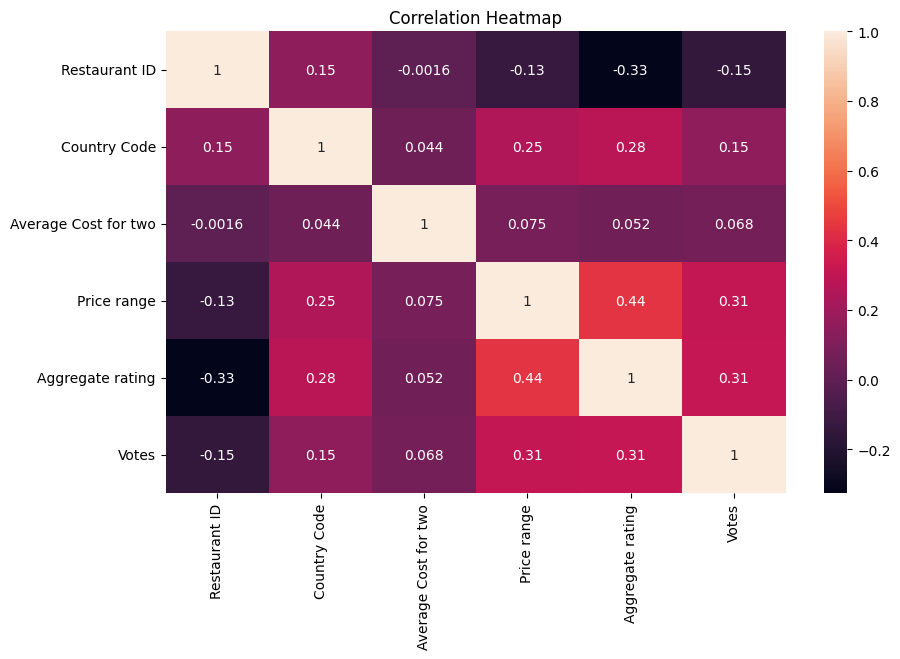

In [17]:
plt.figure(figsize=(10,6))
sns.heatmap(data.corr(numeric_only=True), annot=True)
plt.title("Correlation Heatmap")
plt.show()

#Business Insights Report

1. Most restaurants are concentrated in a few major cities, showing higher food business activity in urban areas.

2. Restaurants that provide online delivery services generally have better customer ratings compared to restaurants without online delivery.

3. The majority of restaurants fall within the medium price range, indicating that customers prefer affordable dining options.

4. Some cuisines are significantly more popular than others, showing strong customer preference trends in food categories.

5. Higher-priced restaurants do not always receive higher ratings, which suggests that customer satisfaction depends more on service and quality than price alone.


#Most Surprising Finding

One surprising finding was that expensive restaurants did not always receive higher ratings. Many affordable restaurants had excellent ratings and customer satisfaction. This indicates that food quality and service are more important to customers than pricing alone.
